# ASR Statistics Plots

This notebook compares ASR models with a mixed metric policy for 4-model comparison:
- segmented clips: use ORC-WER
- non-segmented clips: use mrs_WER

Cross-model error per clip $i$ and model $m$:

$$
\text{error}^{\text{cross}}_{i,m}=\begin{cases}
\text{ORC-WER}_{i,m}, & \text{if segmented} \\
\text{mrs\_WER}_{i,m}, & \text{if non-segmented}
\end{cases}
$$

Condition mean error (for SNR/OVR plots):

$$
\overline{\text{error}}_{m,c}=\frac{1}{N_{m,c}}\sum_{i\in c}\text{error}^{\text{cross}}_{i,m}
$$

The faster-whisper vs whisperx pairwise scatter uses ORC-WER only.

Average inference time per item (not per batch):

$$
\text{time\_per\_item}_m=\frac{\sum_b \text{duration}_{m,b}}{\sum_b \text{items}_{m,b}}
$$

In [ ]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "WER_Results_by_Model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "WER_Results_by_Model"
MANIFEST_PATH = PROJECT_ROOT / "Output" / "manifest.csv"
TIMINGS_PATH = PROJECT_ROOT / "timings_100_random.json"
PLOTS_DIR = PROJECT_ROOT / "Output" / "plot"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PAIRWISE_ORC_WER_MODELS = ["faster-whisper", "whisperx"]
MODEL_ORDER = ["faster-whisper", "whisperx", "parakeet", "wav2vec2"]
MODEL_COLORS = {
    "faster-whisper": "#1f77b4",
    "whisperx": "#ff7f0e",
    "parakeet": "#2ca02c",
    "wav2vec2": "#d62728",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Plots dir: {PLOTS_DIR}")
print(f"Timings file: {TIMINGS_PATH}")

Project root: /home/jamin/Year3Proj
Results dir: /home/jamin/Year3Proj/WER_Results_by_Model
Plots dir: /home/jamin/Year3Proj/Output/plot
Timings file: /home/jamin/Year3Proj/timings_100_random.json


In [2]:
def load_model_results(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    rows = []
    for result_path in sorted(results_dir.glob("*_wer_results.json")):
        with open(result_path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        model = payload.get("model", result_path.stem.replace("_wer_results", ""))
        for item in payload.get("results", []):
            metrics = item.get("metrics", {}) if item.get("status") == "success" else {}
            row = {
                "model": model,
                "clip_id": item.get("clip_id"),
                "status": item.get("status"),
                "metric_type": item.get("metric_type"),
                "wer_method": item.get("wer_method", np.nan),
                "wer": metrics.get("wer", np.nan),
                "mrs_wer": metrics.get("mrs_wer", np.nan),
                "orc_wer": metrics.get("orc_wer", np.nan),
            }
            rows.append(row)
    return pd.DataFrame(rows)


def _format_snr_label(value) -> str:
    if pd.isna(value):
        return "clean"
    numeric = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric):
        return str(value)
    return f"{float(numeric):g}"


def load_manifest(manifest_path: Path = MANIFEST_PATH) -> pd.DataFrame:
    manifest = pd.read_csv(manifest_path)
    keep_cols = [col for col in ["clip_id", "overlap_ratio_target", "overlap_ratio_actual", "snr_db", "noise_type"] if col in manifest.columns]
    manifest = manifest[keep_cols].copy()
    if "snr_db" in manifest.columns:
        manifest["snr_label"] = manifest["snr_db"].apply(_format_snr_label)
    if "overlap_ratio_target" in manifest.columns:
        manifest["ovr_label"] = manifest["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")
    return manifest


def _count_items_from_timing_key(key: str, prefix: str) -> int:
    suffix = key.replace(f"transcribe_{prefix}_", "", 1)
    parts = [chunk for chunk in suffix.split("_-") if chunk]
    return len(parts)


def load_timings(timings_path: Path = TIMINGS_PATH) -> pd.DataFrame:
    with open(timings_path, "r", encoding="utf-8") as handle:
        timings = json.load(handle)
    rows = []
    model_prefixes = {
        "faster-whisper": "faster_whisper",
        "wav2vec2": "wav2vec2",
        "parakeet": "parakeet",
        "whisperx": "whisperx",
    }
    for key, duration in timings.items():
        for model_name, prefix in model_prefixes.items():
            if key.startswith(f"transcribe_{prefix}_"):
                rows.append(
                    {
                        "model": model_name,
                        "duration_sec": float(duration),
                        "item_count": _count_items_from_timing_key(key, prefix),
                        "batch_key": key,
                    }
                )
                break
    return pd.DataFrame(rows)


CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


results_df = load_model_results()
manifest_df = load_manifest()
timings_df = load_timings()

results_df = results_df[results_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()

status_summary_df = (
    results_df.groupby(["model", "status"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

results_df = results_df.merge(manifest_df, on="clip_id", how="left")

# Cross-model metric policy: ORC-WER for segmented, mrs_WER for non-segmented.
results_df["is_segmented"] = pd.notna(results_df["orc_wer"])
results_df["cross_metric_name"] = np.where(results_df["is_segmented"], "ORC-WER", "mrs_WER")
results_df["cross_model_error"] = np.where(results_df["is_segmented"], results_df["orc_wer"], results_df["mrs_wer"])
results_df["cross_model_error_clipped"] = results_df["cross_model_error"].clip(upper=1.0)
results_df["wer_minus_mrs_wer"] = results_df["wer"] - results_df["mrs_wer"]

successful_df = results_df[results_df["status"] == "success"].copy()
successful_df = successful_df[pd.notna(successful_df["cross_model_error"])].copy()

summary_df = (
    successful_df.groupby("model")
    .agg(
        clips=("clip_id", "count"),
        mean_error=("cross_model_error", "mean"),
        median_error=("cross_model_error", "median"),
        mean_error_clipped=("cross_model_error_clipped", "mean"),
        pct_error_gt_1=("cross_model_error", lambda s: 100.0 * (s > 1).mean()),
    )
    .reset_index()
)

metric_breakdown_df = (
    successful_df.groupby(["model", "cross_metric_name"])
.agg(
        clips=("clip_id", "count"),
        mean_error=("cross_model_error", "mean"),
    )
    .reset_index()
)

method_summary_df = (
    successful_df.dropna(subset=["wer_method"])
.groupby(["model", "wer_method"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

three_metric_table_df = (
    successful_df.groupby("model", as_index=False)
    .agg(
        clips=("clip_id", "count"),
        wer_mean=("wer", "mean"),
        mrs_wer_mean=("mrs_wer", "mean"),
        orc_wer_mean=("orc_wer", "mean"),
        wer_minus_mrs_wer_mean=("wer_minus_mrs_wer", "mean"),
        wer_minus_mrs_wer_median=("wer_minus_mrs_wer", "median"),
        wer_minus_mrs_wer_abs_mean=("wer_minus_mrs_wer", lambda s: np.nanmean(np.abs(s))),
    )
)

print(f"Loaded {len(results_df)} filtered clip results across {results_df['model'].nunique()} models")
print("\nStatus counts after regex filter:")
print(status_summary_df.sort_values(["model", "status"]))
print("\nPer-model cross-metric error summary:")
print(summary_df)
print("\nMetric breakdown (ORC-WER vs mrs_WER):")
print(metric_breakdown_df.sort_values(["model", "cross_metric_name"]))
print("\nPer-model table of WER, MRS-WER, ORC-WER, and WER-MRS-WER difference:")
print(three_metric_table_df.sort_values("model"))
if not method_summary_df.empty:
    print("\nWER method usage by model:")
    print(method_summary_df)

missing_success_models = [
    model for model in MODEL_ORDER
    if model in set(results_df["model"]) and model not in set(successful_df["model"])
]
if missing_success_models:
    print("\nWarning: models with zero successful rows in filtered subset:")
    for model in missing_success_models:
        print(f"- {model}")

Loaded 2440 filtered clip results across 4 models

Status counts after regex filter:
            model   status  clips
0  faster-whisper  success    610
1        parakeet  success    610
2        wav2vec2  success    610
3        whisperx  success    610

Per-model cross-metric error summary:
            model  clips  mean_error  median_error  mean_error_clipped  \
0  faster-whisper    610    0.761549      0.772346            0.756725   
1        parakeet    610    0.555026      0.583974            0.555026   
2        wav2vec2    610    0.233423      0.201895            0.233423   
3        whisperx    610    0.731198      0.735577            0.728902   

   pct_error_gt_1  
0        2.131148  
1        0.000000  
2        0.000000  
3        0.819672  

Metric breakdown (ORC-WER vs mrs_WER):
            model cross_metric_name  clips  mean_error
0  faster-whisper             ORC-WER    610    0.761549
1        parakeet           mrs_WER    610    0.555026
2        wav2vec2           

In [3]:
# Compare MRS_WER vs WER separately for no-overlap and overlap clips.
overlap_col = "overlap_ratio_target" if "overlap_ratio_target" in results_df.columns else "overlap_ratio_actual"
if overlap_col not in results_df.columns:
    print("No overlap column found in results_df (expected overlap_ratio_target or overlap_ratio_actual).")
else:
    wer_mrs_df = results_df[
        (results_df["status"] == "success")
        & pd.notna(results_df["wer"])
        & pd.notna(results_df["mrs_wer"])
    ].copy()

    overlap_values = pd.to_numeric(wer_mrs_df[overlap_col], errors="coerce").fillna(0.0)
    wer_mrs_df["overlap_group"] = np.where(np.isclose(overlap_values, 0.0), "no_overlap", "overlap")
    wer_mrs_df["wer_minus_mrs_wer"] = wer_mrs_df["wer"] - wer_mrs_df["mrs_wer"]
    wer_mrs_df["abs_diff"] = wer_mrs_df["wer_minus_mrs_wer"].abs()

    comparison_summary_df = (
        wer_mrs_df.groupby(["model", "overlap_group"], as_index=False)
        .agg(
            clips=("clip_id", "count"),
            wer_mean=("wer", "mean"),
            mrs_wer_mean=("mrs_wer", "mean"),
            diff_mean=("wer_minus_mrs_wer", "mean"),
            diff_median=("wer_minus_mrs_wer", "median"),
            abs_diff_mean=("abs_diff", "mean"),
            pct_wer_gt_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * (s > 0).mean()),
            pct_wer_lt_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * (s < 0).mean()),
            pct_wer_eq_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * np.isclose(s, 0.0).mean()),
        )
        .sort_values(["model", "overlap_group"])
    )

    print("WER vs MRS_WER comparison split by overlap group:")
    display(comparison_summary_df.round(4))

    comparison_pivot_df = comparison_summary_df.pivot(
        index="model", columns="overlap_group", values=["wer_mean", "mrs_wer_mean", "diff_mean", "abs_diff_mean"]
    )
    print("Compact pivot view (model x overlap_group):")
    display(comparison_pivot_df.round(4))

WER vs MRS_WER comparison split by overlap group:


,model,overlap_group,clips,wer_mean,mrs_wer_mean,diff_mean,diff_median,abs_diff_mean,pct_wer_gt_mrs,pct_wer_lt_mrs,pct_wer_eq_mrs
0,faster-whisper,no_overlap,10,0.0459,0.0473,-0.0014,0.0000,0.0026,10.0000,10.0000,80.0000
1,faster-whisper,overlap,600,0.1825,0.1770,0.0055,0.0000,0.0152,40.5000,19.6667,39.8333
2,parakeet,no_overlap,10,0.3122,0.3122,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000
3,parakeet,overlap,600,0.5483,0.5591,-0.0107,0.0000,0.0219,29.5000,36.0000,34.5000
4,wav2vec2,no_overlap,10,0.0573,0.0627,-0.0054,0.0000,0.0067,10.0000,10.0000,80.0000
5,wav2vec2,overlap,600,0.2561,0.2363,0.0199,0.0111,0.0208,77.3333,5.3333,17.3333
6,whisperx,no_overlap,10,0.0326,0.0337,-0.0011,0.0000,0.0011,0.0000,10.0000,90.0000
7,whisperx,overlap,600,0.2210,0.2215,-0.0005,0.0000,0.0092,24.3333,16.6667,59.0000


Compact pivot view (model x overlap_group):


wer_mean         mrs_wer_mean          diff_mean          \
overlap_group  no_overlap overlap   no_overlap overlap no_overlap overlap   
model                                                                       
faster-whisper     0.0459  0.1825       0.0473  0.1770    -0.0014  0.0055   
parakeet           0.3122  0.5483       0.3122  0.5591     0.0000 -0.0107   
wav2vec2           0.0573  0.2561       0.0627  0.2363    -0.0054  0.0199   
whisperx           0.0326  0.2210       0.0337  0.2215    -0.0011 -0.0005   

               abs_diff_mean          
overlap_group     no_overlap overlap  
model                                 
faster-whisper        0.0026  0.0152  
parakeet              0.0000  0.0219  
wav2vec2              0.0067  0.0208  
whisperx              0.0011  0.0092

In [4]:
# Top-3 worst performing files per model (using stats_utils helpers).
import sys

code_dir = PROJECT_ROOT / "Code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

from stats_utils import load_wer_json, build_analysis_df

worst_rows = []
for result_path in sorted(RESULTS_DIR.glob("*_wer_results.json")):
    payload = load_wer_json(str(result_path))
    model_name = payload.get("model", result_path.stem.replace("_wer_results", ""))

    analysis_df = build_analysis_df(payload, include_failed=False)
    analysis_df = analysis_df[
        analysis_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)
    ].copy()
    if analysis_df.empty:
        continue

    if "model_name" in analysis_df.columns and analysis_df["model_name"].notna().any():
        model_name = analysis_df["model_name"].dropna().iloc[0]

    top3 = (
        analysis_df
        .dropna(subset=["error_value", "clip_id"])
        .sort_values("error_value", ascending=False)
        .head(3)
        .copy()
    )
    if top3.empty:
        continue

    top3["model"] = model_name
    worst_rows.append(
        top3[[
            "model",
            "clip_id",
            "metric_type",
            "error_value",
            "snr_db",
            "overlap_ratio",
            "noise_type",
        ]]
    )

if worst_rows:
    worst_per_model = pd.concat(worst_rows, ignore_index=True)
    worst_per_model = worst_per_model.sort_values(
        ["model", "error_value"], ascending=[True, False]
    ).reset_index(drop=True)

    # Display-friendly SNR label: NaN/None means no-noise condition.
    worst_per_model_display = worst_per_model.copy()
    worst_per_model_display["snr_db"] = worst_per_model_display["snr_db"].apply(
        lambda v: "no noise" if pd.isna(v) else f"{float(v):g}"
    )

    print("Top-3 worst performing files per model (higher error is worse):")
    display(worst_per_model_display)
else:
    print("No successful rows with error values were found after applying CROSS_MODEL_CLIP_REGEX.")

Top-3 worst performing files per model (higher error is worse):


,model,clip_id,metric_type,error_value,snr_db,overlap_ratio,noise_type
0,faster-whisper,mix_0001115_0.14_2_-5_T,orc_wer,1.609929,-5,0.14,T
1,faster-whisper,mix_0001109_0.14_2_7.4_T,orc_wer,1.468085,7.4,0.14,T
2,faster-whisper,mix_0001106_0.14_2_None_T,orc_wer,1.425532,no noise,0.14,T
3,parakeet,mix_0001238_0.14_2_None_T,wer,1.000000,no noise,0.14,T
4,parakeet,mix_0000290_0.14_2_None_T,wer,0.980132,no noise,0.14,T
5,parakeet,mix_0000686_0.14_2_None_T,wer,0.978723,no noise,0.14,T
6,wav2vec2,mix_0000323_0.14_2_-5_T,wer,0.665217,-5,0.14,T
7,wav2vec2,mix_0000899_0.14_2_-5_T,wer,0.646341,-5,0.14,T
8,wav2vec2,mix_0000563_0.14_2_-5_T,wer,0.619318,-5,0.14,T
9,whisperx,mix_0001226_0.14_2_None_T,orc_wer,1.373563,no noise,0.14,T


In [5]:
# Inspect top-3 worst files per model using ref from manifest.csv and hyp from ASR_transcriptions.json.
import ast
import textwrap
from pathlib import Path
from IPython.display import Markdown, display

def _normalize_ws(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def _manifest_transcript_to_text(raw_value):
    text = _normalize_ws(raw_value)
    if not text:
        return ""
    try:
        parsed = ast.literal_eval(text)
    except Exception:
        return text

    pieces = []
    if isinstance(parsed, list):
        for item in parsed:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            else:
                pieces.append(_normalize_ws(item))
    else:
        pieces.append(_normalize_ws(parsed))
    return " ".join([p for p in pieces if p])

def _hyp_transcript_to_text(raw_value):
    pieces = []
    if isinstance(raw_value, list):
        for item in raw_value:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            elif isinstance(item, dict):
                pieces.append(_normalize_ws(item.get("text") or item.get("transcript")))
            else:
                pieces.append(_normalize_ws(item))
    elif raw_value is not None:
        pieces.append(_normalize_ws(raw_value))
    return " ".join([p for p in pieces if p])

def _wrap(text, width=120):
    txt = text or ""
    if not txt:
        return "[empty]"
    return "\n".join(textwrap.wrap(txt, width=width, break_long_words=False))

if "worst_per_model" not in globals() or worst_per_model.empty:
    print("Run Cell 4 first to generate worst_per_model.")
else:
    manifest_path = PROJECT_ROOT / "Output" / "manifest.csv"
    hyp_path = PROJECT_ROOT / "ASR_transcriptions.json"

    manifest_lookup = {}
    manifest_raw = pd.read_csv(manifest_path, usecols=["clip_id", "transcript"])

    for _, r in manifest_raw.iterrows():
        manifest_lookup[r["clip_id"]] = _manifest_transcript_to_text(r["transcript"])

    with open(hyp_path, "r", encoding="utf-8") as handle:
        hyp_payload = json.load(handle)

    compare_rows = []
    for _, row in worst_per_model.iterrows():
        clip_id = row["clip_id"]
        model_name = row["model"]

        ref_text = manifest_lookup.get(clip_id, "")

        clip_bundle = hyp_payload.get(clip_id, {}) if isinstance(hyp_payload, dict) else {}
        transcript_map = clip_bundle.get("transcript", {}) if isinstance(clip_bundle, dict) else {}
        hyp_raw = transcript_map.get(model_name) if isinstance(transcript_map, dict) else None
        hyp_text = _hyp_transcript_to_text(hyp_raw)

        compare_rows.append(
            {
                "model": model_name,
                "clip_id": clip_id,
                "metric_type": row.get("metric_type"),
                "error_value": row.get("error_value"),
                "ref_text": ref_text or "[not found in manifest]",
                "hyp_text": hyp_text or "[not found in ASR_transcriptions]",
            }
        )

    compare_df = pd.DataFrame(compare_rows)
    compare_df = compare_df.sort_values(["model", "error_value"], ascending=[True, False]).reset_index(drop=True)

    print("Readable transcript comparison for top-3 worst files per model:")
    for model_name, group in compare_df.groupby("model", sort=True):
        display(Markdown(f"## {model_name}"))
        for rank, (_, r) in enumerate(group.iterrows(), start=1):
            block = [
                f"### {rank}. {r['clip_id']}",
                f"- metric: {r['metric_type']}",
                f"- error: {float(r['error_value']):.4f}",
                "",
                "**Reference (manifest.csv):**",
                "```text",
                _wrap(r["ref_text"]),
                "```",
                "",
                "**Hypothesis (ASR_transcriptions.json):**",
                "```text",
                _wrap(r["hyp_text"]),
                "```",
            ]
            display(Markdown("\n".join(block)))

    # Keep structured table available for downstream analysis if needed.
    pd.set_option("display.max_colwidth", 220)

Readable transcript comparison for top-3 worst files per model:


## faster-whisper

### 1. mix_0001115_0.14_2_-5_T
- metric: orc_wer
- error: 1.6099

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the con... They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last
week. Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US President,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. I never had peace of mind. There was no frequency. You can make a
big deal out of it. Be careful. I can not do this. I am a good man, and I will not be the same. I am the civil servant.
My name is George. Be careful. Let everyone know. I have a new mission, and I have a vision. I am going to protect our
nation. Don't you dare! I am a terrorist! I am going to protect our nation. I am going to protect our nation.
```

### 2. mix_0001109_0.14_2_7.4_T
- metric: orc_wer
- error: 1.4681

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the... They might be broken, but they are not defeated. Her condition was yesterday
described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to tell a bit
of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not that bad.
It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last week.
Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US president,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. It has not changed my life. We are all affected. But you can
learn about the situation. The United States Government and the United States Constitutional and Constitutional
Commission will make a code for the United States. The International Commission on Civil Rights will implement a code
for the United States Constitutional and Constitutional Commission. The United States Government will implement the
code. We have all the information we need.
```

### 3. mix_0001106_0.14_2_None_T
- metric: orc_wer
- error: 1.4255

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the... They might be broken, but they are not defeated. Her condition was yesterday
described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to tell a bit
of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not that bad.
It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last week.
Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US President,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. Thank you for watching. Like, comment, share. Subscribe, and
comment with has Panamera and me. Thank you. It is really too late to leave. Happy Venue several of at Imamsouk. We are
young people who consider the life of a woman a고요ouss of population. Life in the world is just a stage. The world is in
front of us. In the touristic exp prompt.
```

...

### 3. mix_0000563_0.14_2_-5_T
- metric: wer
- error: 0.6193

**Reference (manifest.csv):**
```text
There is no other solution to congestion in Edinburgh. That's the day job. Johnson was pretty low. It was a double
tragedy for the family. THE HUE OF THE GOLDEN GATE THAT OPENS THE SUNSET WAY TO MYSTIC AND TERRIBLE CATHAY AND HINDUSTAN
THE ENEMY OF CALIFORNIA SAYS THE STATE IS MAGNIFICENT BUT THIN They receive a high profile in the media. Brown is an
interesting man, but he is not desperate. Gaelic provision continued to be good. It could take years for the tunnel to
be reopened. THEY SHOUT THEIR STATISTICS ACROSS THE ROCKIES AND THE DESERTS TO NEW YORK THE MISSISSIPPI VALLEY IS NON
EXISTENT TO THE CALIFORNIAN HIS FELLOW FEELING IS FOR THE OPPOSITE COAST LINE The track is currently covered in snow.
Feel the air, the space. That must be left to the Parole Board. It was one in the afternoon. That is bound to happen.
ALREADY THE CALIFORNIA SORT IN THE COMMERCIAL CHANNELS HAS BECOME THE BROADLY ACCEPTED IF MEDIOCRE NATIONAL FORM PEOPLE
WHO REVERE THE PILGRIM FATHERS OF SIXTEEN TWENTY
```

**Hypothesis (ASR_transcriptions.json):**
```text
THERE IS NO OTHER SOLUTION TO CONGESTION IN EDINBURGH THAT'S THE DAYJOF JOHNSON WAS PRETTY LOW IT WAS A DOUBLE ECOGEL OT
OF THE BOWLIN GATE THAT OPENS THE SUNSET WAY TO MYSTIC AND TERRIBLE CAFAY AND INDES HIN THE ENEMY OF CALIFORNIA SAYS THE
STATE IS MAGNIFICENTLY RECEIVE A HYROPAL I LEMEDIA RIN IS INTERESTING THAT HIS NOT DESPERATE GALI PARISIAI ATIITTITIT
ETIHE IS TIS CON ISETISTICIPROS TE BROTEETETICS TIE CAL E ISIS OABE GALLY IS NONIES TITO TE CALI PORN HIS FELLOW BE IS
TOT THE FOD IS THA POS DRIVE AS CORDLY COVETENS SNOW REAL BE ATHIS BATBUT MUST BE LEFTTTO THE PUL EI IT WAS ONE OF THE
AFTERNOONALREAY HISTBAHALLAHAUN AND ITS SORT AND THECOMMERCIAL CHANNELS HAS BECOME THE BRODLY ACCEPT TIT I MEBEOOR
NATIONAL FOR HE PL WIL REVEARE THE FELFROM FATHERS OF SIXTEEN TWENTY
```

## whisperx

### 1. mix_0001226_0.14_2_None_T
- metric: orc_wer
- error: 1.3736

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fwy. Rydyn ni wedi gweithio'n bob amser nad ydyn ni'n byth ddod yn ôl o ffotbol
Cymraeg. Nid yw. Mae Halifax hefyd wedi'i ddweud ei bod yn ymwneud â phredator. Yn anhygoel, roedd United yn dal yn fyw.
Mae gennym ymrwymiad gwasanaeth. Mae wedi'i wneud hynny gyda'r adroddiad gwych. Mae'n dweud peth. Mae'n dweud peth.
Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n d
Florida yw'r sefydliad pivotal yn y wlad. Nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn y Llyfrgell Gwladol. Mae'r
Cymdeithas Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n hollol wahanol. Mae'n ymdrechu ychydig. Mae'n ymdrechu
hefyd gyda'r newydd. Ond roeddwn i'n iawn. Roedd ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig
ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychyd ac mae'r ddau
ffyrdd yn ymwneud â'r hawliau. Mae'r broblem yma yw a allai fod yn cael ei hyrwyddo.
```

### 2. mix_0001235_0.14_2_-5_T
- metric: orc_wer
- error: 1.3506

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fawr am fwy. Rydyn ni wedi gweithredu bob amser nad oeddwn ni'n byw'n gwneud
rhywbeth ar ôl chwaraewr Cymru. Nid y byddwn ni'n gwneud hynny. Mae Halifax hefyd wedi'i ddweud ei bod yn ymddangos fel
predator. Yn anodd, ond, roedd United yn dal yn fyw. Rydyn ni'n cael ysgrifennu. Mae wedi'i wneud hynny gyda'r adroddiad
gwych. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n
Fflorida yw'r sefydliad pivotal yn y wlad. Ond nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn y Llyfrgell Gwladol. Mae'r
Cymru Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n hollol wahanol. Mae'n ymdrech hefyd, gyda'r newydd. Ond
roeddwn i'n gwres. Roedd ychydig adnoddau penodol ynghylch y cyfrifiad. Mae hynny'n ychydig o genius. Mae hynny'n
cydweithio mewn ffyrdd ychydig o ffyrdd ychydig o ffyrdd ychydig o ffyrdd ychydig o ffyrdd ac mae'r ddau ffyrdd yn
ymwneud â'r gorffennol. Mae'r broblem fawr yw a allai fod yn cael ei ddefnyddio.
```

### 3. mix_0001229_0.14_2_7.4_T
- metric: orc_wer
- error: 1.3333

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fawr i bawb. Rydyn ni wedi gweithredu bob amser nad ydyn ni'n byw'n gwneud
rhywbeth sy'n ddiddorol i'r chwaraewr Cymru. Nid y byddai'n ei wneud. Mae Halifax hefyd wedi'i ddweud ei bod yn
ymddangos fel ymgyrch. Yn anodd, ond, roedd United yn dal yn fyw. Rydyn ni'n cael ysgrifenni. Mae wedi'i wneud hynny
gyda'r adroddiad gwych. Mae'n ddweud peth o'r 0.06. Roedd hi'n cymryd ychydig o awr i'r gas i'w gadael. Mae'n anodd
Fflorida yw'r sefydliad pivotal yn y wlad. Ond nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn ysbrydol fwyaf. Mae'r
Uniaeth Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n wahanol iawn. Mae'n ymdrech hefyd, gyda'r newydd. Ond
roeddwn i'n gwrs. Roedd ychydig ymddangos gwirioneddol ynghylch y cyfrifiad. Mae hynny'n ymwneud â'r ffordd ychydig
ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ac mae'r ddau ffyrdd yn ymwneud â'r hawliau. Mae'r
broblem ychydig yw a allai fod yn cael ei ddefnyddio.
```

In [6]:
# load transcription of clip clip_id as (remove speaker and time info)
clip_id = "mix_0000047_0.00_2_-5_T" 
print(manifest_lookup.get(clip_id, ""))


AND THAT THERE IS MORE MEANT IN THINGS THAN MEETS THE EYE MY HAND IS TO ME WHAT YOUR HEARING AND SIGHT TOGETHER ARE TO YOU IN LARGE MEASURE WE TRAVEL THE SAME HIGHWAYS READ THE SAME BOOKS SPEAK THE SAME LANGUAGE NO BUT THE PYES ARE AN EXCEPTION TO EVERY KNOWN RULE THAT'S WHAT DECLARED MISSUS RACHEL WITH CONVICTION REALLY HELD AN ASSORTMENT OF FIRECRACKERS AND PINWHEELS FOR WHICH WARREN SLOANE HAD SENT TO TOWN BY SAINT CLAIR DONNELL'S FATHER THE DAY BEFORE INTENDING TO HAVE A BIRTHDAY CELEBRATION THAT EVENING I AM GLAD TO TAKE YOU BY THE HAND AND LEAD YOU ALONG AN UNTRODDEN WAY INTO A WORLD WHERE THE HAND IS SUPREME BUT AT THE VERY OUTSET WE ENCOUNTER A DIFFICULTY YOU ARE SO ACCUSTOMED TO LIGHT TAKE YOUR SEAT AND WORK OUT THE SIX PROBLEMS ON PAGE EIGHTY FOUR OF YOUR ARITHMETIC FOR PUNISHMENT SAID ANNE SAINT CLAIR LOOKED RATHER AMAZED AT HER TONE BUT HE WENT MEEKLY TO HIS DESK AND TOOK OUT HIS SLATE THEN HE STEALTHILY PASSED A SMALL PARCEL TO JOE SLOANE ACROSS THE AISLE


In [7]:
def model_palette(model_names):
    return {model: MODEL_COLORS.get(model, "#333333") for model in model_names}


def plot_metric_vs_condition(data: pd.DataFrame, condition_col: str, title: str, ylabel: str, filename: str) -> None:
    plot_data = data.dropna(subset=[condition_col, "cross_model_error"]).copy()
    plot_data[condition_col] = pd.to_numeric(plot_data[condition_col], errors="coerce")
    plot_data = plot_data.dropna(subset=[condition_col])
    plot_data = plot_data.sort_values(condition_col)

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=plot_data,
        x=condition_col,
        y="cross_model_error",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=model_palette(MODEL_ORDER),
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        linewidth=2.2,
    )
    plt.title(title)
    plt.xlabel(condition_col.replace("_", " ").upper())
    plt.ylabel(ylabel)
    plt.legend(title="Model", frameon=True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=200)
    plt.show()


def add_reference_line(ax):
    low, high = ax.get_xlim()
    ax.plot([low, high], [low, high], linestyle="--", color="#555555", linewidth=1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)


print("Plot helpers ready")

# Average inference time per item: total duration / total number of items.
timing_summary = (
    timings_df.groupby("model", as_index=False)
    .agg(total_duration_sec=("duration_sec", "sum"), total_items=("item_count", "sum"))
)
timing_summary["sec_per_item"] = timing_summary["total_duration_sec"] / timing_summary["total_items"]
timing_summary = timing_summary.sort_values("sec_per_item", ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(
    data=timing_summary,
    x="model",
    y="sec_per_item",
    order=timing_summary["model"],
    hue="model",
    hue_order=timing_summary["model"],
    palette=model_palette(timing_summary["model"]),
    legend=False,
)
plt.title("Average Inference Time per Item by Model")
plt.xlabel("Model")
plt.ylabel("Seconds per item")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "average_timing_per_item_by_model.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png",
    "metric_composition_by_model.png",
    "error_distribution_by_model_and_metric_family.png",
    "average_timing_per_item_by_model.png",
]:
    print(f"- {PLOTS_DIR / plot_name}")

Plot helpers ready


KeyError: 'model'

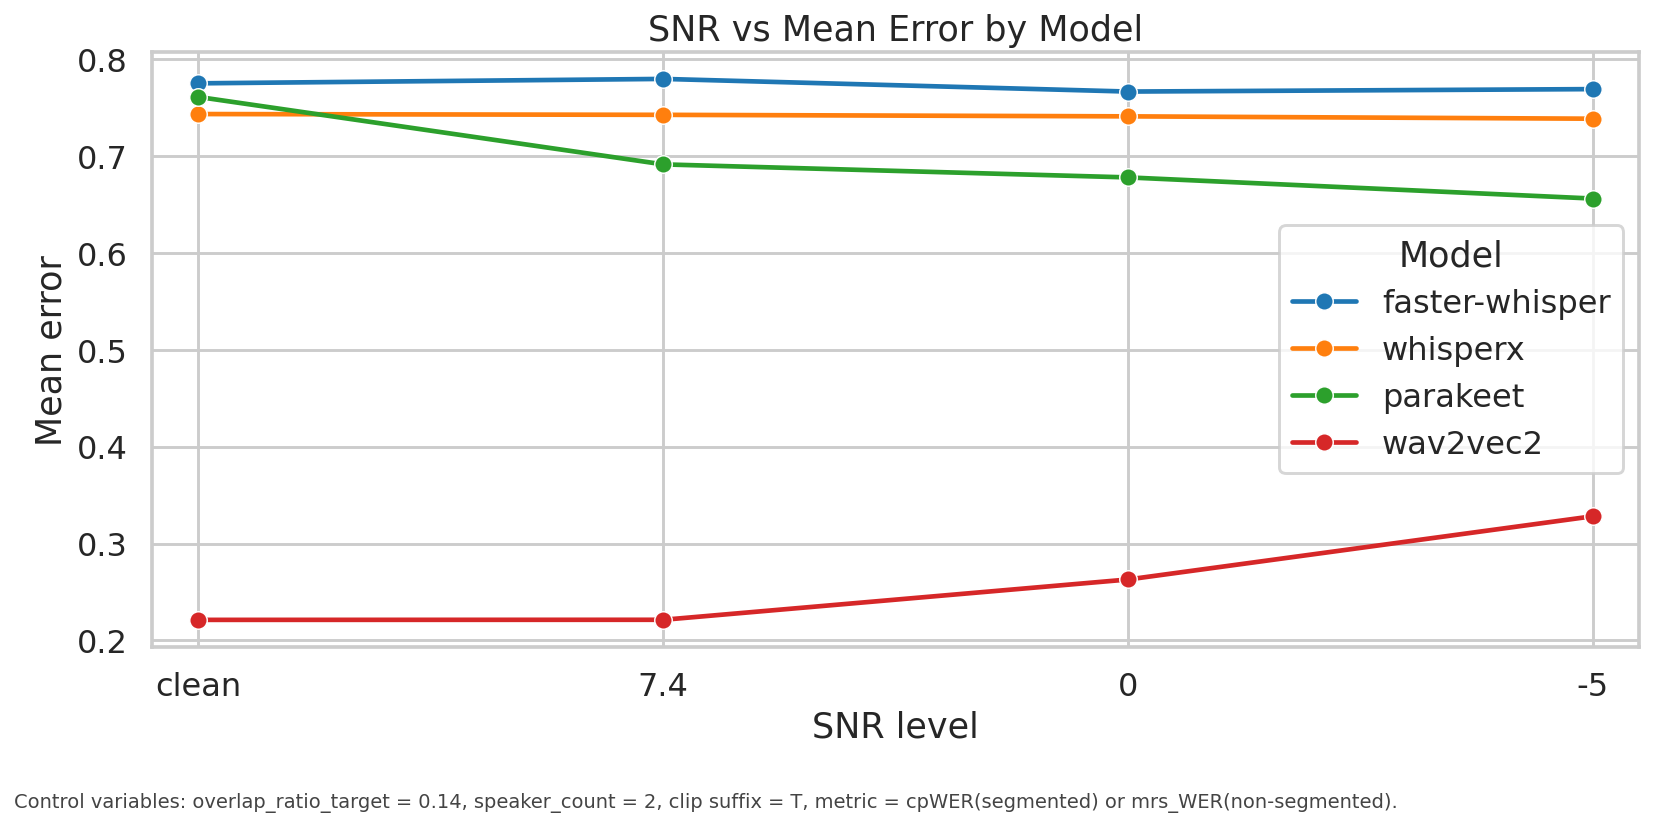

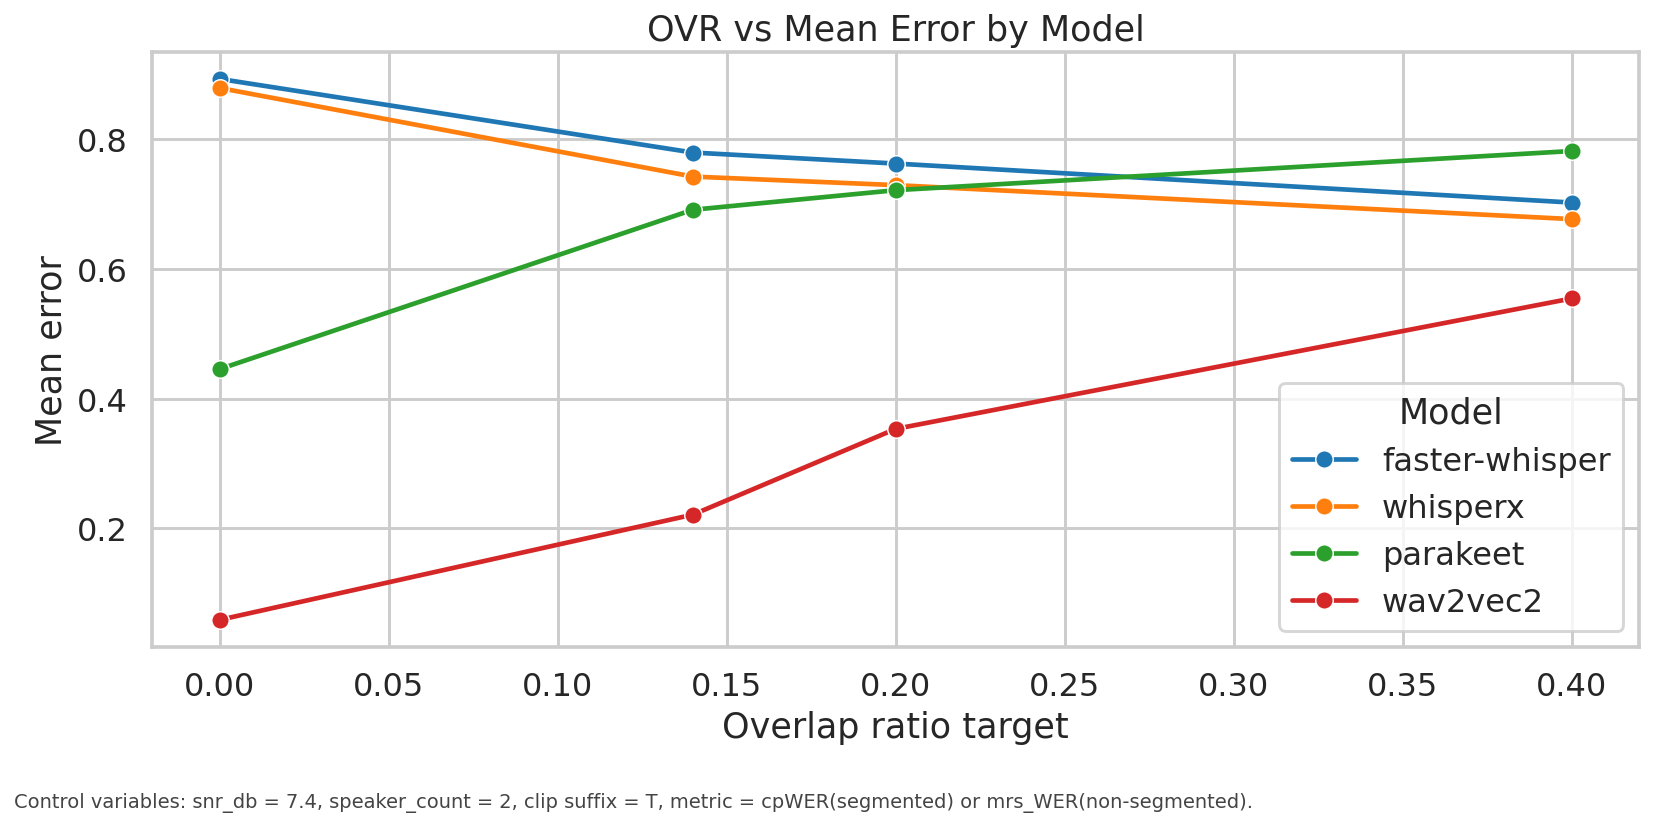

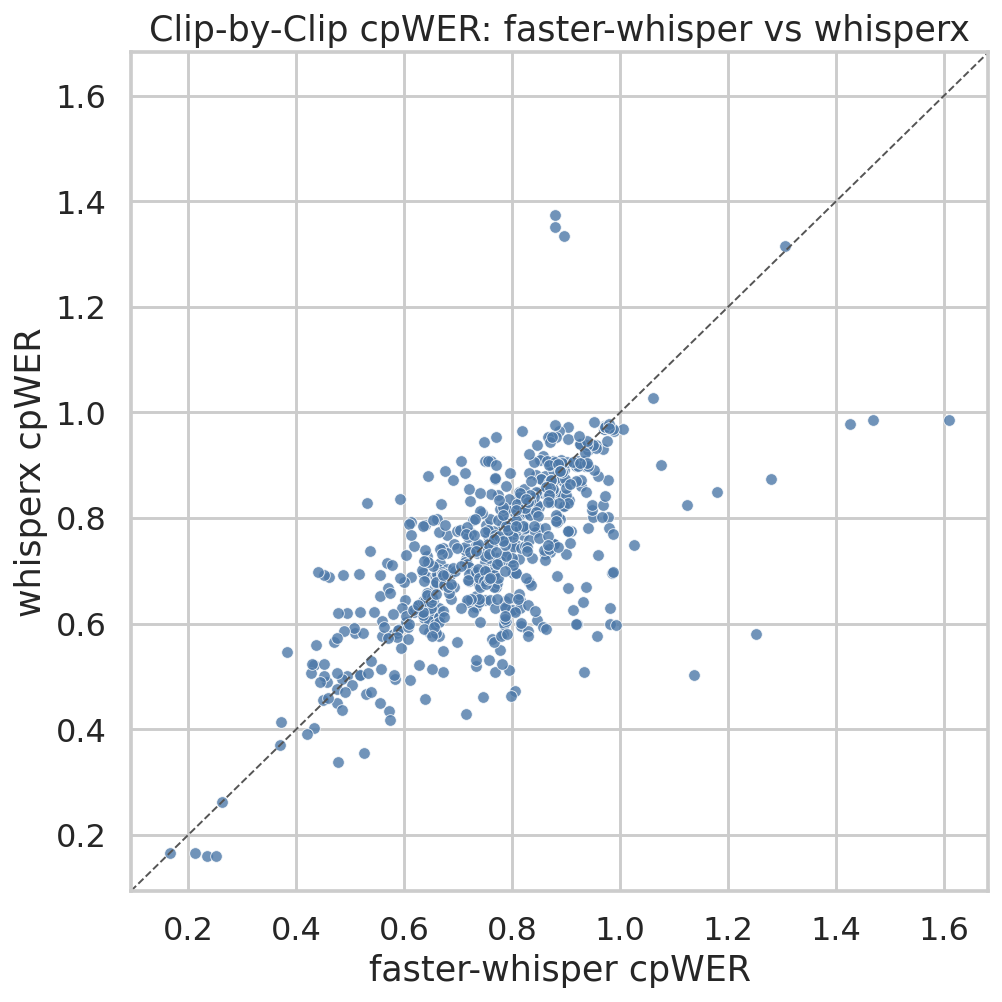

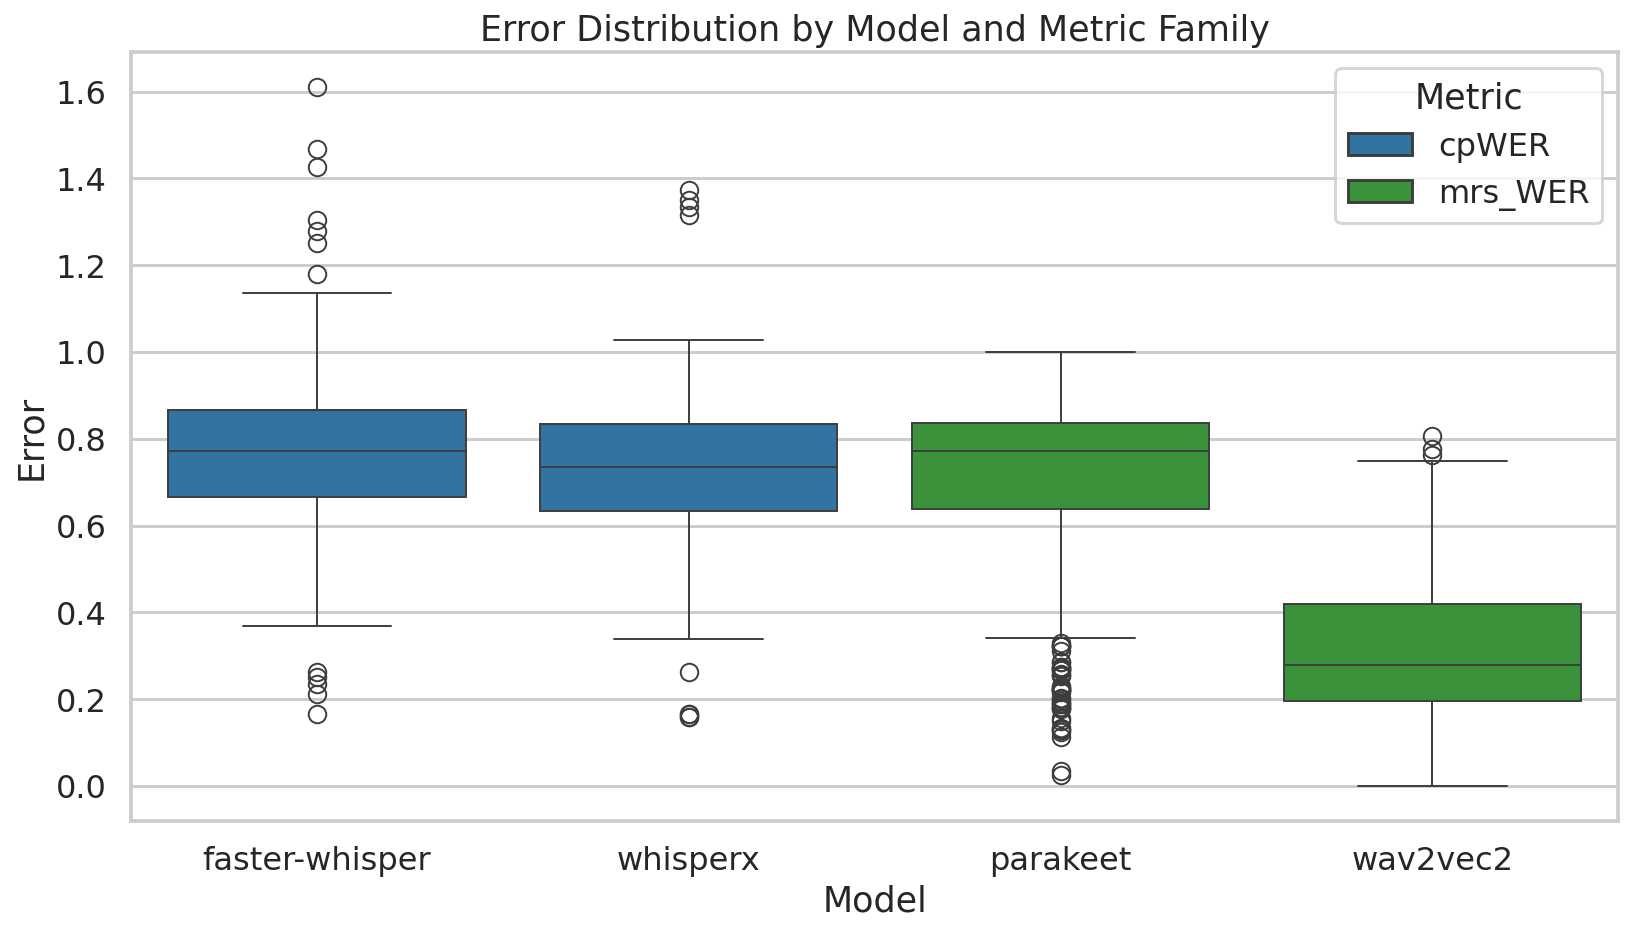

Saved plots to:
- /home/jamin/Year3Proj/Output/plot/snr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/ovr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png
- /home/jamin/Year3Proj/Output/plot/error_distribution_by_model_and_metric_family.png


In [ ]:
# SNR vs mean cross-model error with explicit order: clean, 7.4, 0, -5.
# Controlled setting for this plot: overlap_ratio_target = 0.14 (OVR fixed).
snr_order = ["clean", "7.4", "0", "-5"]
snr_pos = {label: idx for idx, label in enumerate(snr_order)}

snr_plot_df = successful_df.dropna(subset=["snr_label", "cross_model_error", "overlap_ratio_target"]).copy()
snr_plot_df["snr_label"] = snr_plot_df["snr_label"].astype(str)
snr_plot_df = snr_plot_df[snr_plot_df["snr_label"].isin(snr_order)]
snr_plot_df = snr_plot_df[np.isclose(snr_plot_df["overlap_ratio_target"].astype(float), 0.14)]

snr_summary = (
    snr_plot_df.groupby(["model", "snr_label"], as_index=False)["cross_model_error"]
    .mean()
)
snr_summary["snr_pos"] = snr_summary["snr_label"].map(snr_pos)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=snr_summary,
    x="snr_pos",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
 )
plt.xticks([0, 1, 2, 3], snr_order)
plt.xlim(-0.1, 3.1)
plt.title("SNR vs Mean Error by Model")
plt.xlabel("SNR level")
plt.ylabel("Mean error")
plt.legend(title="Model")
snr_caption = "Control variables: overlap_ratio_target = 0.14, speaker_count = 2, clip suffix = T, metric = ORC-WER(segmented) or mrs_WER(non-segmented)."
plt.gcf().text(0.01, 0.01, snr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "snr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# OVR vs mean cross-model error for each model.
# Controlled setting for this plot: snr_db = 7.4 (SNR fixed).
ovr_plot_df = successful_df.dropna(subset=["overlap_ratio_target", "snr_label", "cross_model_error"]).copy()
ovr_plot_df["snr_label"] = ovr_plot_df["snr_label"].astype(str)
ovr_plot_df = ovr_plot_df[ovr_plot_df["snr_label"] == "7.4"]

ovr_summary = (
    ovr_plot_df.groupby(["model", "overlap_ratio_target"], as_index=False)["cross_model_error"]
    .mean()
    .sort_values(["model", "overlap_ratio_target"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ovr_summary,
    x="overlap_ratio_target",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
 )
plt.title("OVR vs Mean Error by Model")
plt.xlabel("Overlap ratio target")
plt.ylabel("Mean error")
plt.legend(title="Model")
ovr_caption = "Control variables: snr_db = 7.4, speaker_count = 2, clip suffix = T, metric = ORC-WER(segmented) or mrs_WER(non-segmented)."
plt.gcf().text(0.01, 0.01, ovr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "ovr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# Clip-by-clip comparison between faster-whisper and whisperx using ORC-WER only.
fw_whisperx = (
    results_df.loc[results_df["model"].isin(PAIRWISE_ORC_WER_MODELS) & (results_df["status"] == "success"),
                  ["clip_id", "model", "orc_wer"]]
    .dropna()
    .pivot(index="clip_id", columns="model", values="orc_wer")
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7.5, 7.5))
ax = sns.scatterplot(
    data=fw_whisperx,
    x="faster-whisper",
    y="whisperx",
    s=36,
    alpha=0.8,
    color="#4c78a8",
)
add_reference_line(ax)
plt.title("Clip-by-Clip ORC-WER: faster-whisper vs whisperx")
plt.xlabel("faster-whisper ORC-WER")
plt.ylabel("whisperx ORC-WER")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png", dpi=200)
plt.show()

# Useful interpretation plot 1: metric composition by model (how much ORC-WER vs mrs_WER contributes).
metric_mix = (
    successful_df.groupby(["model", "cross_metric_name"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)
metric_pivot = metric_mix.pivot(index="model", columns="cross_metric_name", values="clips").fillna(0)
metric_ratio = metric_pivot.div(metric_pivot.sum(axis=1), axis=0).reset_index()
metric_ratio_long = metric_ratio.melt(id_vars="model", var_name="metric", value_name="ratio")


# Useful interpretation plot 2: error distribution split by metric family.
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=successful_df,
    x="model",
    y="cross_model_error",
    hue="cross_metric_name",
    order=MODEL_ORDER,
    hue_order=["ORC-WER", "mrs_WER"],
    palette={"ORC-WER": "#1f77b4", "mrs_WER": "#2ca02c"},
)
plt.title("Error Distribution by Model and Metric Family")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "error_distribution_by_model_and_metric_family.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png",
    "error_distribution_by_model_and_metric_family.png"
]:
    print(f"- {PLOTS_DIR / plot_name}")

Transferability comparison: synthetic -> real


,model,real_metric,synthetic_metric,real_count,synthetic_total,synthetic_successful,synthetic_success_rate,real_mean,synthetic_mean,gap_real_minus_synth,ratio_real_over_synth,synthetic_rank,real_rank,rank_shift_real_minus_synth
0,parakeet,wer,mrs_wer,100,3720,650,0.1747,0.3886,0.7071,-0.3185,0.5496,2.0,1.0,-1.0
1,wav2vec2,wer,mrs_wer,100,3720,3720,1.0000,0.7228,0.5064,0.2164,1.4273,1.0,2.0,1.0
2,whisperx,orc_wer,orc_wer,100,3720,628,0.1688,0.8355,0.7369,0.0986,1.1339,3.0,3.0,0.0
3,faster-whisper,orc_wer,orc_wer,100,3720,1544,0.4151,0.8949,0.7760,0.1189,1.1533,4.0,4.0,0.0


/tmp/ipykernel_14403/97978083.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


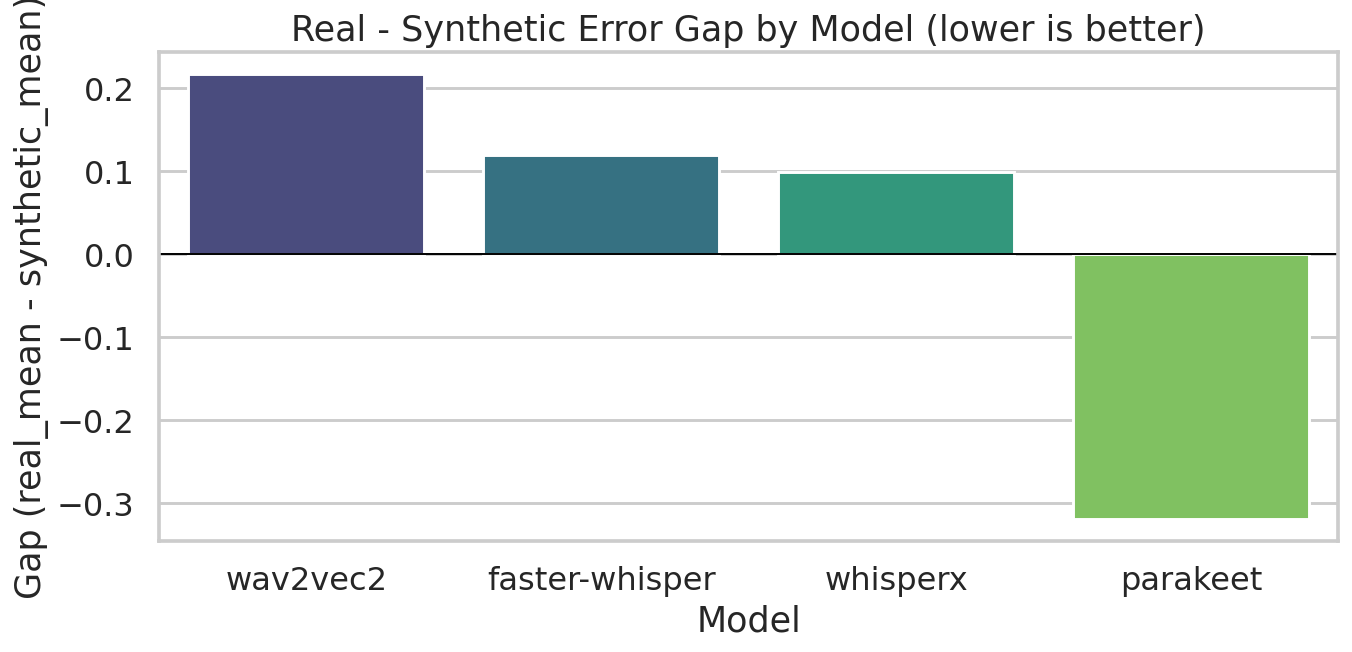

Mean relative degradation (real vs synthetic): 6.60%


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
SYN_DIR = ROOT / "WER_Results_by_Model"

with open(REAL_EVAL_PATH, "r", encoding="utf-8") as f:
    real_eval = json.load(f)

# Build real-data stats from per-clip entries so we preserve metric type per model.
real_rows = []
for clip_id, per_model in real_eval.get("by_clip", {}).items():
    for model_name, result in per_model.items():
        real_rows.append(
            {
                "clip_id": clip_id,
                "model": model_name,
                "metric": result.get("metric"),
                "score": result.get("score"),
            }
        )

real_df = pd.DataFrame(real_rows)
if real_df.empty:
    raise RuntimeError("No real-data evaluation rows found in Output/real_eval_results.json")

real_model_summary = (
    real_df.groupby("model")
    .agg(
        real_count=("score", "size"),
        real_mean=("score", "mean"),
        real_median=("score", "median"),
        real_min=("score", "min"),
        real_max=("score", "max"),
    )
    .reset_index()
)

real_metric_mode = (
    real_df.groupby("model")["metric"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index(name="real_metric")
)
real_model_summary = real_model_summary.merge(real_metric_mode, on="model", how="left")


def _pick_synthetic_mean(summary: dict, preferred_metric: str):
    """Pick a synthetic mean metric compatible with real metric for fair transferability comparison."""
    if preferred_metric == "orc_wer":
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]

    for key in ("mrs_wer_mean", "wer_mean", "orc_wer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


syn_rows = []
for model_file in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(model_file, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model")
    summary = payload.get("summary", {})

    # If model is missing in real summary, we still keep synthetic row.
    preferred_metric = (
        real_model_summary.loc[real_model_summary["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary["model"])
        else "mrs_wer"
    )
    syn_metric, syn_mean = _pick_synthetic_mean(summary, preferred_metric)

    syn_rows.append(
        {
            "model": model,
            "synthetic_metric": syn_metric,
            "synthetic_mean": syn_mean,
            "synthetic_total": summary.get("total", np.nan),
            "synthetic_successful": summary.get("successful", np.nan),
            "synthetic_success_rate": (
                (summary.get("successful", 0) / summary.get("total", 1))
                if summary.get("total", 0)
                else np.nan
            ),
        }
    )

syn_df = pd.DataFrame(syn_rows)

transfer_df = real_model_summary.merge(syn_df, on="model", how="outer")
transfer_df["gap_real_minus_synth"] = transfer_df["real_mean"] - transfer_df["synthetic_mean"]
transfer_df["ratio_real_over_synth"] = transfer_df["real_mean"] / transfer_df["synthetic_mean"]

# Lower is better for WER/ORC-WER, so positive gap means degradation on real data.
transfer_df["synthetic_rank"] = transfer_df["synthetic_mean"].rank(method="min")
transfer_df["real_rank"] = transfer_df["real_mean"].rank(method="min")
transfer_df["rank_shift_real_minus_synth"] = transfer_df["real_rank"] - transfer_df["synthetic_rank"]

transfer_df = transfer_df.sort_values("real_mean", ascending=True).reset_index(drop=True)

cols = [
    "model",
    "real_metric",
    "synthetic_metric",
    "real_count",
    "synthetic_total",
    "synthetic_successful",
    "synthetic_success_rate",
    "real_mean",
    "synthetic_mean",
    "gap_real_minus_synth",
    "ratio_real_over_synth",
    "synthetic_rank",
    "real_rank",
    "rank_shift_real_minus_synth",
]

print("Transferability comparison: synthetic -> real")
display(transfer_df[cols].round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=transfer_df.sort_values("gap_real_minus_synth", ascending=False),
    x="model",
    y="gap_real_minus_synth",
    palette="viridis",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Real - Synthetic Error Gap by Model (lower is better)")
plt.ylabel("Gap (real_mean - synthetic_mean)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# Weighted headline figure: average relative degradation across comparable models.
valid = transfer_df.dropna(subset=["ratio_real_over_synth"])
if not valid.empty:
    rel_deg = (valid["ratio_real_over_synth"] - 1.0) * 100.0
    print(f"Mean relative degradation (real vs synthetic): {rel_deg.mean():.2f}%")


Transferability by overlap ratio


,model,ovr_label,clips,real_metric,real_mean,synthetic_mean,gap_real_minus_synth
0,faster-whisper,0.00,10,orc_wer,0.8949,0.8933,0.0017
1,faster-whisper,0.14,400,orc_wer,0.8949,0.7727,0.1223
2,faster-whisper,0.20,100,orc_wer,0.8949,0.7627,0.1322
3,faster-whisper,0.40,100,orc_wer,0.8949,0.7026,0.1924
4,parakeet,0.00,10,wer,0.3886,0.4457,-0.0571
5,parakeet,0.14,400,wer,0.3886,0.6967,-0.3081
6,parakeet,0.20,100,wer,0.3886,0.7217,-0.3331
7,parakeet,0.40,100,wer,0.3886,0.7821,-0.3935
8,wav2vec2,0.00,10,wer,0.7228,0.0590,0.6638
9,wav2vec2,0.14,400,wer,0.7228,0.2584,0.4645


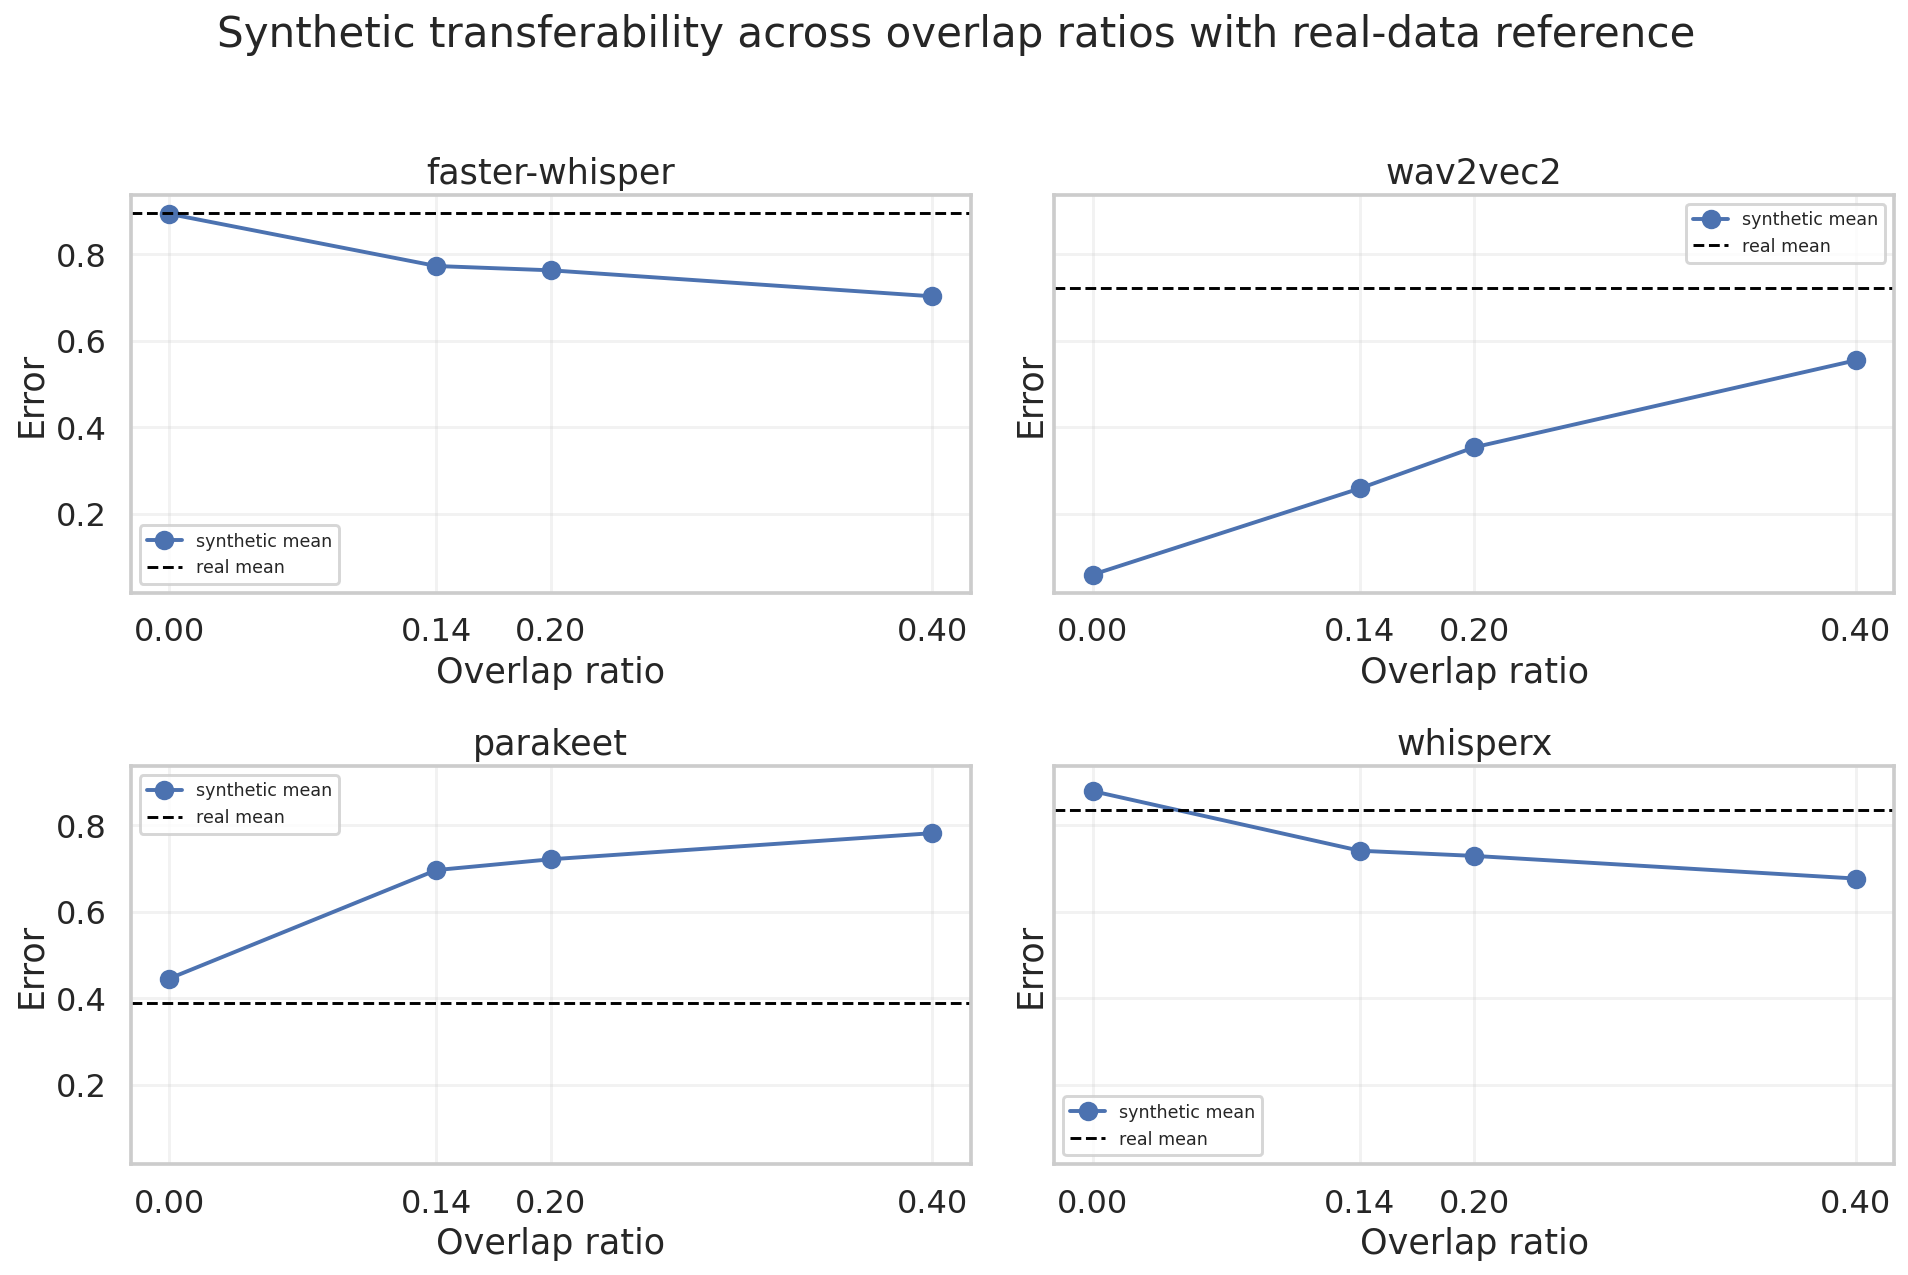

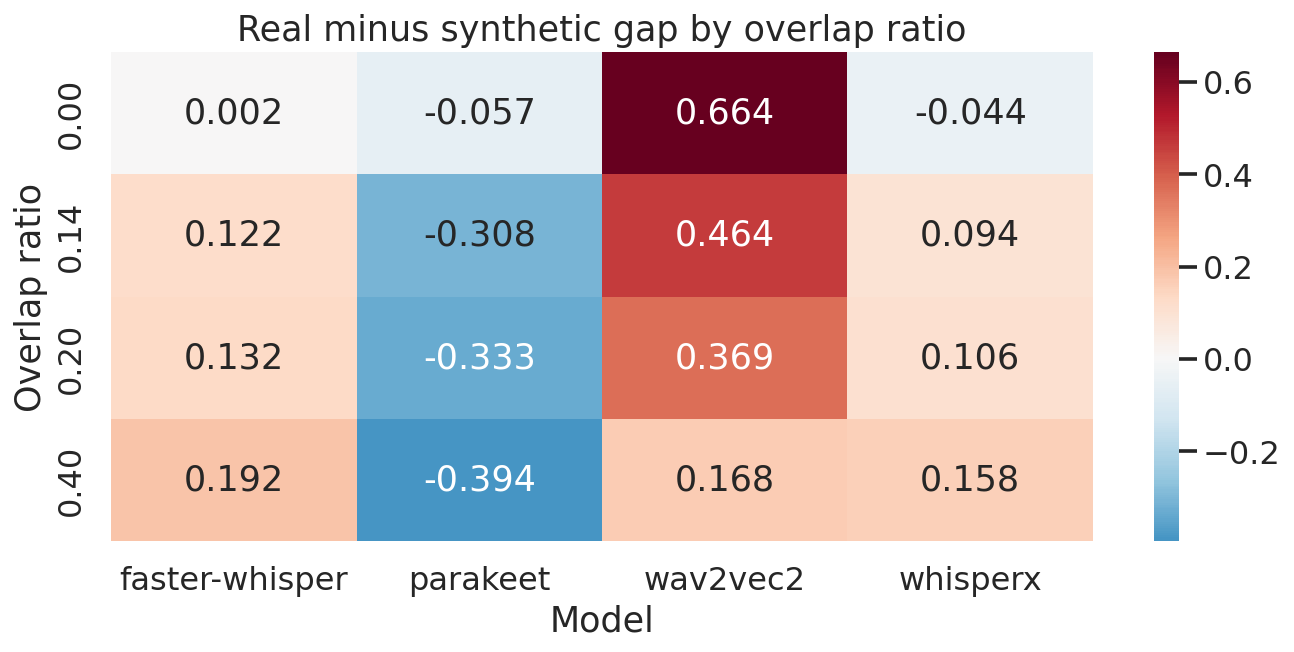

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
MANIFEST_PATH = ROOT / "Output" / "manifest.csv"
SYN_DIR = ROOT / "WER_Results_by_Model"
CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


def _pick_mean(summary: dict, preferred_metric: str):
    if preferred_metric == "orc_wer":
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]

    for key in ("mrs_wer_mean", "wer_mean", "orc_wer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


def _real_summary_from_eval(real_eval_path: Path) -> pd.DataFrame:
    with open(real_eval_path, "r", encoding="utf-8") as f:
        real_eval = json.load(f)

    rows = []
    for clip_id, per_model in real_eval.get("by_clip", {}).items():
        for model_name, result in per_model.items():
            rows.append(
                {
                    "clip_id": clip_id,
                    "model": model_name,
                    "metric": result.get("metric"),
                    "score": result.get("score"),
                }
            )

    real_df = pd.DataFrame(rows)
    if real_df.empty:
        raise RuntimeError("No rows found in Output/real_eval_results.json")

    real_summary = (
        real_df.groupby("model")
        .agg(
            real_count=("score", "size"),
            real_mean=("score", "mean"),
            real_median=("score", "median"),
        )
        .reset_index()
)
    real_metric_mode = (
        real_df.groupby("model")["metric"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index(name="real_metric")
    )
    return real_summary.merge(real_metric_mode, on="model", how="left")


manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
if "overlap_ratio_target" not in manifest_df.columns:
    raise RuntimeError("Manifest is missing overlap_ratio_target; cannot build OVR comparison.")
manifest_df["ovr_label"] = manifest_df["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")

real_model_summary_ovr = _real_summary_from_eval(REAL_EVAL_PATH)

synthetic_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    summary = payload.get("summary", {})
    preferred_metric = (
        real_model_summary_ovr.loc[real_model_summary_ovr["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary_ovr["model"])
        else "mrs_wer"
    )
    synthetic_metric, synthetic_mean = _pick_mean(summary, preferred_metric)
    synthetic_rows.append(
        {
            "model": model,
            "synthetic_metric": synthetic_metric,
            "synthetic_mean": synthetic_mean,
        }
    )

synthetic_model_summary = pd.DataFrame(synthetic_rows)

# Load the per-clip synthetic results so we can compare across overlap ratios.
clip_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    for item in payload.get("results", []):
        if item.get("status") != "success":
            continue
        metrics = item.get("metrics", {})
        clip_rows.append(
            {
                "model": model,
                "clip_id": item.get("clip_id"),
                "metric_type": item.get("metric_type"),
                "cross_error": metrics.get("orc_wer") if pd.notna(metrics.get("orc_wer", np.nan)) else metrics.get("mrs_wer"),
                "orc_wer": metrics.get("orc_wer", np.nan),
                "wer": metrics.get("wer", np.nan),
                "mrs_wer": metrics.get("mrs_wer", np.nan),
            }
        )

synthetic_clip_df = pd.DataFrame(clip_rows)
synthetic_clip_df = synthetic_clip_df[synthetic_clip_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
synthetic_clip_df = synthetic_clip_df.merge(manifest_df[["clip_id", "overlap_ratio_target", "ovr_label"]], on="clip_id", how="left")
synthetic_clip_df["synthetic_metric"] = np.where(pd.notna(synthetic_clip_df["orc_wer"]), "orc_wer", "mrs_wer")
synthetic_clip_df["synthetic_error"] = np.where(pd.notna(synthetic_clip_df["orc_wer"]), synthetic_clip_df["orc_wer"], synthetic_clip_df["mrs_wer"])

ovr_compare_df = (
    synthetic_clip_df.groupby(["model", "overlap_ratio_target", "ovr_label"], as_index=False)
    .agg(
        synthetic_mean=("synthetic_error", "mean"),
        clips=("clip_id", "count"),
    )
    .merge(real_model_summary_ovr[["model", "real_mean", "real_metric"]], on="model", how="left")
)
ovr_compare_df["gap_real_minus_synth"] = ovr_compare_df["real_mean"] - ovr_compare_df["synthetic_mean"]
ovr_compare_df = ovr_compare_df.sort_values(["model", "overlap_ratio_target"]).reset_index(drop=True)

print("Transferability by overlap ratio")
display(
    ovr_compare_df[
        ["model", "ovr_label", "clips", "real_metric", "real_mean", "synthetic_mean", "gap_real_minus_synth"]
    ].round(4)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()
for ax, model in zip(axes, ["faster-whisper", "wav2vec2", "parakeet", "whisperx"]):
    model_df = ovr_compare_df[ovr_compare_df["model"] == model].copy()
    if model_df.empty:
        ax.set_axis_off()
        continue

    x = model_df["overlap_ratio_target"].astype(float)
    ax.plot(x, model_df["synthetic_mean"], marker="o", linewidth=2, label="synthetic mean")
    ax.axhline(model_df["real_mean"].iloc[0], linestyle="--", color="black", linewidth=1.5, label="real mean")
    ax.set_title(model)
    ax.set_xlabel("Overlap ratio")
    ax.set_ylabel("Error")
    ax.set_xticks(sorted(model_df["overlap_ratio_target"].astype(float).unique()))
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle("Synthetic transferability across overlap ratios with real-data reference", y=1.02)
plt.tight_layout()
plt.show()

pivot_gap = ovr_compare_df.pivot_table(
    index="ovr_label",
    columns="model",
    values="gap_real_minus_synth",
    aggfunc="mean",
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_gap.sort_index(), annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Real minus synthetic gap by overlap ratio")
plt.xlabel("Model")
plt.ylabel("Overlap ratio")
plt.tight_layout()
plt.show()
